# **Cervical Cancer Detection using Python**

In [6]:
# Install necessary libraries
!pip install opencv-python tensorflow keras scikit-image scikit-learn seaborn matplotlib

/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [7]:
# Import necessary libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.segmentation import slic
from skimage.color import label2rgb
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [8]:
# SLIC Segmentation
def apply_slic(image_path, num_segments=100):

    img = cv2.imread(image_path)
    img = cv2.resize(img, (224, 224))

    # SLIC
    segments = slic(img, n_segments=num_segments, compactness=10, start_label=1)

    superpixel_image = label2rgb(segments, img, kind='avg')
    # uint8
    superpixel_image = (superpixel_image * 255).astype(np.uint8)
    return superpixel_image

In [9]:
def preprocess_dataset(input_dir, output_dir, num_segments=100):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    for class_name in os.listdir(input_dir):
        class_path = os.path.join(input_dir, class_name)
        save_path = os.path.join(output_dir, class_name)
        os.makedirs(save_path, exist_ok=True)

        for img_file in os.listdir(class_path):
            img_path = os.path.join(class_path, img_file)
            try:
                processed_img = apply_slic(img_path, num_segments)
                save_file = os.path.join(save_path, img_file)
                cv2.imwrite(save_file, processed_img)
            except Exception as e:
                print(f"Error processing {img_path}: {e}")

In [11]:
train_dir = "/kaggle/input/sipakmed/SingleCellPAP/Training"
test_dir = "/kaggle/input/sipakmed/SingleCellPAP/Test"

processed_train_dir = "/kaggle/working/processed_Training"
processed_test_dir = "/kaggle/working/processed_Test"

preprocess_dataset(train_dir, processed_train_dir, num_segments=100)
preprocess_dataset(test_dir, processed_test_dir, num_segments=100)

In [12]:
# Canny Edge Detection
def apply_edge_detection_on_superpixel(superpixel_img):
    gray = cv2.cvtColor(superpixel_img, cv2.COLOR_BGR2GRAY)

    # Canny edge
    edges = cv2.Canny(gray, threshold1=100, threshold2=200)

    superpixel_with_edges = superpixel_img.copy()
    superpixel_with_edges[edges > 0] = [255, 0, 0]  # edges in red

    return superpixel_with_edges

In [13]:
def process_superpixels_with_edges(input_dir, output_dir):

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    for class_name in os.listdir(input_dir):
        class_path = os.path.join(input_dir, class_name)
        save_path = os.path.join(output_dir, class_name)
        os.makedirs(save_path, exist_ok=True)

        for img_file in os.listdir(class_path):
            img_path = os.path.join(class_path, img_file)
            try:
                superpixel_img = cv2.imread(img_path)

                processed_img = apply_edge_detection_on_superpixel(superpixel_img)

                save_file = os.path.join(save_path, img_file)
                cv2.imwrite(save_file, processed_img)
            except Exception as e:
                print(f"Error processing {img_path}: {e}")

In [14]:
processed_train_dir = "/kaggle/working/processed_Training"
processed_test_dir = "/kaggle/working/processed_Test"

processed_with_edges_train_dir = "/kaggle/working/processed_with_edges_Training"
processed_with_edges_test_dir = "/kaggle/working/processed_with_edges_Test"

process_superpixels_with_edges(processed_train_dir, processed_with_edges_train_dir)
process_superpixels_with_edges(processed_test_dir, processed_with_edges_test_dir)

In [15]:
train_dir = "/kaggle/working/processed_with_edges_Training"
test_dir = "/kaggle/working/processed_with_edges_Test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    rotation_range=40,
    brightness_range=[0.8, 1.2]
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 3549 images belonging to 5 classes.
Found 500 images belonging to 5 classes.


In [16]:
# ResNet50
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers[-20:]:
    layer.trainable = True

res_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    layers.Dropout(0.5),
    layers.Dense(5, activation='softmax')
])

res_model.compile(optimizers.Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [17]:
# Train the Model
res_hist = res_model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator,
    callbacks=[early_stopping]
)

Epoch 1/10


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1733766452.904990     130 service.cc:145] XLA service 0x7af974001850 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1733766452.905058     130 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1733766452.905064     130 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1733766482.933450     130 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_26', 20 bytes spill stores, 20 bytes spill loads

I0000 00:00:1733766482.979

111/111 ━━━━━━━━━━━━━━━━━━━━ 136s 685ms/step - accuracy: 0.6004 - loss: 9.1275 - val_accuracy: 0.2000 - val_loss: 9.8518
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 45s 383ms/step - accuracy: 0.8895 - loss: 7.5622 - val_accuracy: 0.2000 - val_loss: 9.1191
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 45s 379ms/step - accuracy: 0.8963 - loss: 6.6470 - val_accuracy: 0.2000 - val_loss: 7.5858
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 45s 380ms/step - accuracy: 0.9301 - loss: 5.7188 - val_accuracy: 0.2000 - val_loss: 8.8506
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 46s 389ms/step - accuracy: 0.9395 - loss: 4.9043 - val_accuracy: 0.1920 - val_loss: 7.3331
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 45s 380ms/step - accuracy: 0.9448 - loss: 4.2077 - val_accuracy: 0.2120 - val_loss: 7.8907
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 45s 382ms/step - accuracy: 0.9509 - loss: 3.5832 - val_accuracy: 0.2380 - val_loss: 6.3955
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 45s 383ms/step - accuracy: 0.9537 - loss: 3.0324 - va

In [18]:
test_loss, test_acc = res_model.evaluate(test_generator)
print("ResNet50 Test Accuracy:", test_acc * 100, "%")

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.8919 - loss: 2.1559
ResNet50 Test Accuracy: 88.99999856948853 %


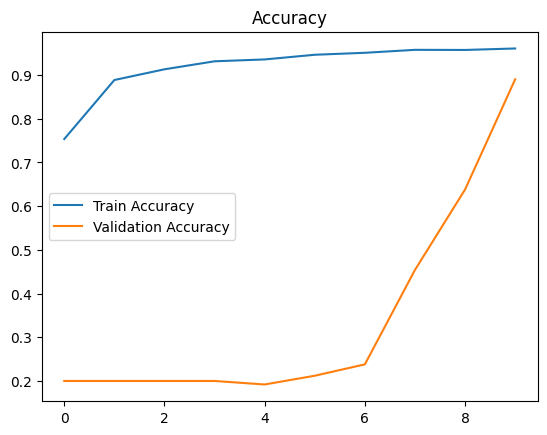

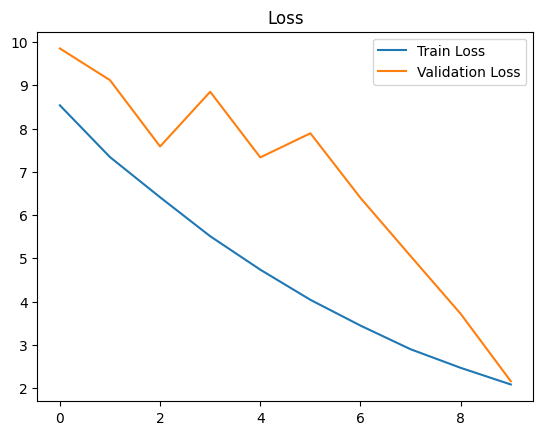

In [19]:
# Plot accuracy
plt.plot(res_hist.history['accuracy'], label='Train Accuracy')
plt.plot(res_hist.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(res_hist.history['loss'], label='Train Loss')
plt.plot(res_hist.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 276ms/step


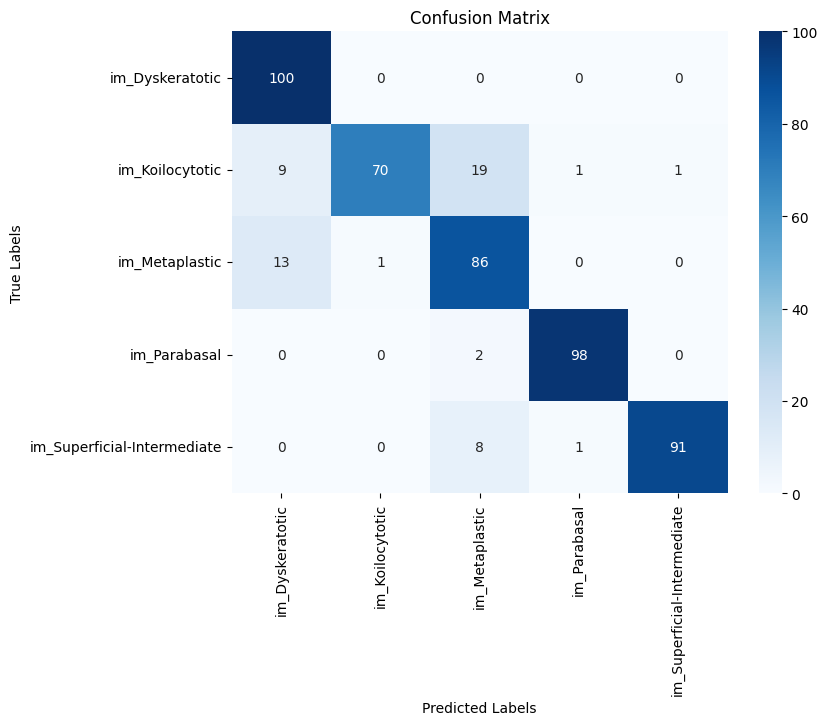

In [20]:
# Confusion matrix
y_pred_prob = res_model.predict(test_generator)
y_true = test_generator.classes
y_pred = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [21]:
# Classification report
report = classification_report(y_true, y_pred, output_dict=True)
print("Classification Report:")
print(report)

Classification Report:
{'0': {'precision': 0.819672131147541, 'recall': 1.0, 'f1-score': 0.9009009009009009, 'support': 100}, '1': {'precision': 0.9859154929577465, 'recall': 0.7, 'f1-score': 0.8187134502923976, 'support': 100}, '2': {'precision': 0.7478260869565218, 'recall': 0.86, 'f1-score': 0.7999999999999999, 'support': 100}, '3': {'precision': 0.98, 'recall': 0.98, 'f1-score': 0.98, 'support': 100}, '4': {'precision': 0.9891304347826086, 'recall': 0.91, 'f1-score': 0.9479166666666667, 'support': 100}, 'accuracy': 0.89, 'macro avg': {'precision': 0.9045088291688836, 'recall': 0.89, 'f1-score': 0.889506203571993, 'support': 500}, 'weighted avg': {'precision': 0.9045088291688836, 'recall': 0.89, 'f1-score': 0.8895062035719931, 'support': 500}}


In [22]:
n_classes = len(test_generator.class_indices)
y_true_onehot = label_binarize(y_true, classes=list(range(n_classes)))

# ROC-AUC score
res_roc_auc = roc_auc_score(y_true_onehot, y_pred_prob, average='macro', multi_class='ovr')
print("Macro-Averaged ROC-AUC for ResNet50: {:.4f}".format(res_roc_auc))

Macro-Averaged ROC-AUC for ResNet50: 0.9878


/tmp/ipykernel_23/976383133.py:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', color='gray')


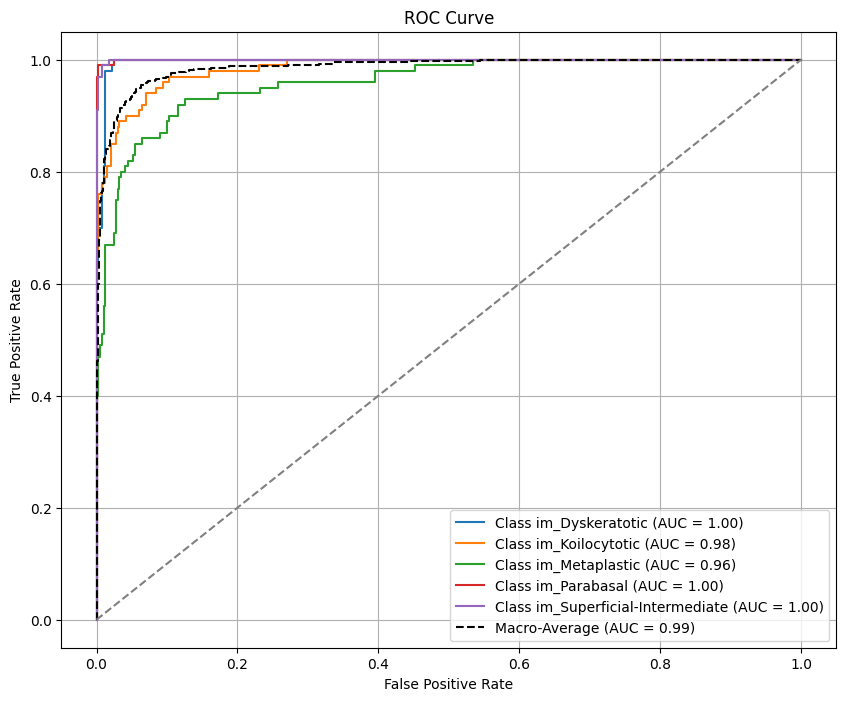

In [23]:
# Plot ROC Curve
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i, label in enumerate(test_generator.class_indices.keys()):
    plt.plot(fpr[i], tpr[i], label=f"Class {label} (AUC = {roc_auc[i]:.2f})")

fpr_micro, tpr_micro, _ = roc_curve(y_true_onehot.ravel(), y_pred_prob.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, linestyle='--', label=f'Macro-Average (AUC = {roc_auc_micro:.2f})', color='black')

plt.plot([0, 1], [0, 1], 'k--', color='gray')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [24]:
# Evaluation metrics
resnet_precision = report['weighted avg']['precision']
resnet_recall = report['weighted avg']['recall']
resnet_f1_score = report['weighted avg']['f1-score']

print("Precision: ", resnet_precision)
print("Recall: ", resnet_recall)
print("F1-Score: ", resnet_f1_score)

Precision:  0.9045088291688836
Recall:  0.89
F1-Score:  0.8895062035719931


In [25]:
# Save the model
res_model.save('/kaggle/working/res_model.h5')
print("Model saved successfully!")

Model saved successfully!


In [26]:
# VGG16
from tensorflow.keras.applications.vgg16 import VGG16
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers[-20:]:
    layer.trainable = True

vgg_model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    layers.Dropout(0.5),
    layers.Dense(5, activation='softmax')
])

vgg_model.compile(optimizers.Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [27]:
# Train the Model
vgg_hist = vgg_model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator,
    callbacks=[early_stopping]
)

Epoch 1/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.1998 - loss: 8.6699 - val_accuracy: 0.2000 - val_loss: 3.4291
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 54s 458ms/step - accuracy: 0.2093 - loss: 2.9781 - val_accuracy: 0.2000 - val_loss: 2.2475
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 53s 455ms/step - accuracy: 0.2106 - loss: 2.1571 - val_accuracy: 0.2000 - val_loss: 1.9651
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 54s 459ms/step - accuracy: 0.2094 - loss: 1.9267 - val_accuracy: 0.2000 - val_loss: 1.8361
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 54s 456ms/step - accuracy: 0.2016 - loss: 1.8154 - val_accuracy: 0.2000 - val_loss: 1.7645
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 54s 457ms/step - accuracy: 0.1934 - loss: 1.7522 - val_accuracy: 0.2000 - val_loss: 1.7210
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 54s 457ms/step - accuracy: 0.2052 - loss: 1.7131 - val_accuracy: 0.2000 - val_loss: 1.6927
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 54s 457ms/step - accuracy: 0.2015 - loss: 1.6

In [28]:
test_loss, test_acc = vgg_model.evaluate(test_generator)
print("VGG16 Test Accuracy:", test_acc * 100, "%")

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - accuracy: 0.2462 - loss: 1.6472
VGG16 Test Accuracy: 20.000000298023224 %


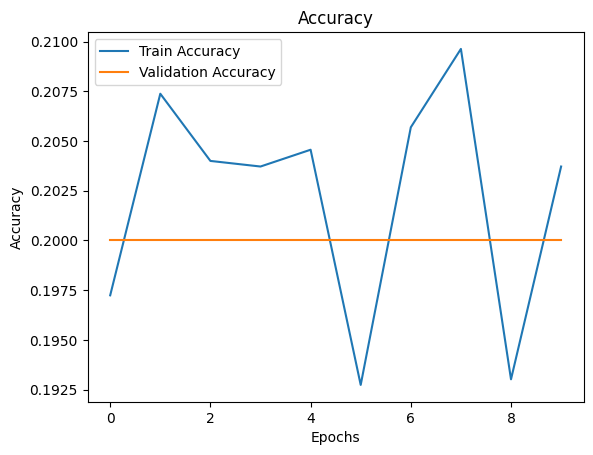

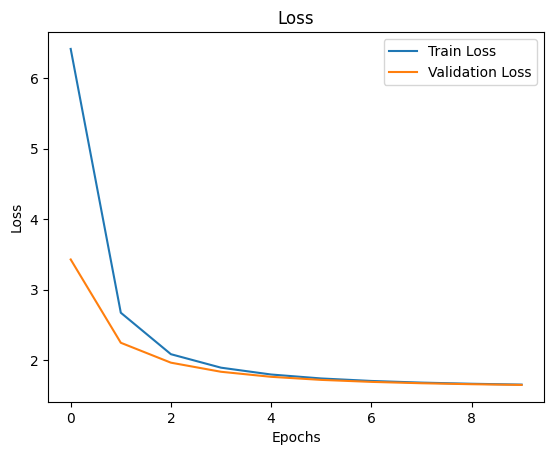

In [29]:
# Plot accuracy
plt.plot(vgg_hist.history['accuracy'], label='Train Accuracy')
plt.plot(vgg_hist.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(vgg_hist.history['loss'], label='Train Loss')
plt.plot(vgg_hist.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 165ms/step


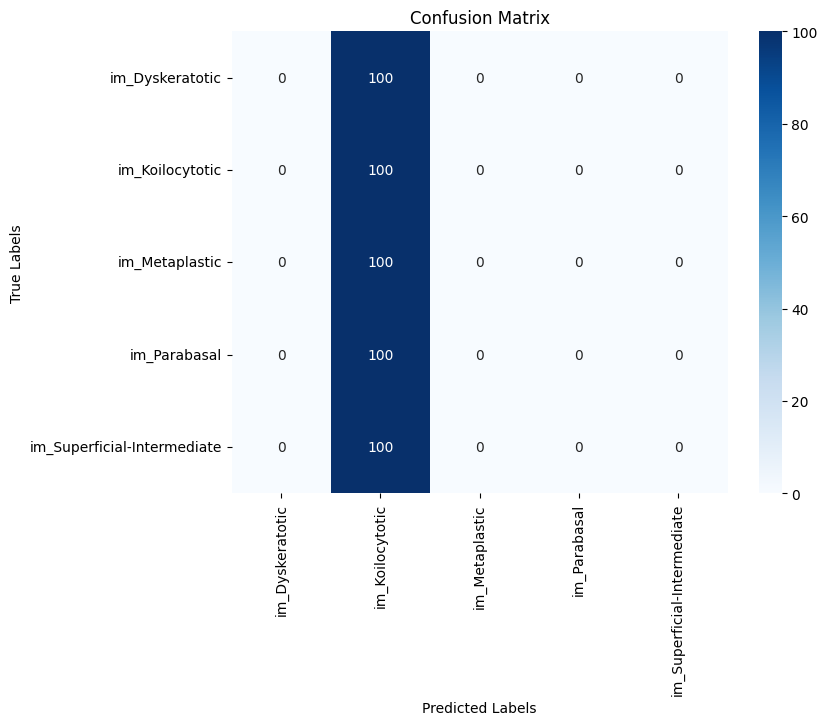

In [30]:
# Confusion matrix
y_pred_prob = vgg_model.predict(test_generator)
y_true = test_generator.classes
y_pred = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [31]:
# Classification report
report = classification_report(y_true, y_pred, output_dict=True)
print("Classification Report:")
print(report)

Classification Report:
{'0': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 100}, '1': {'precision': 0.2, 'recall': 1.0, 'f1-score': 0.33333333333333337, 'support': 100}, '2': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 100}, '3': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 100}, '4': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 100}, 'accuracy': 0.2, 'macro avg': {'precision': 0.04, 'recall': 0.2, 'f1-score': 0.06666666666666668, 'support': 500}, 'weighted avg': {'precision': 0.04, 'recall': 0.2, 'f1-score': 0.06666666666666667, 'support': 500}}


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [32]:
n_classes = len(test_generator.class_indices)
y_true_onehot = label_binarize(y_true, classes=list(range(n_classes)))

# ROC-AUC score
vgg_roc_auc = roc_auc_score(y_true_onehot, y_pred_prob, average='macro', multi_class='ovr')
print("Macro-Averaged ROC-AUC for VGG16: {:.4f}".format(vgg_roc_auc))

Macro-Averaged ROC-AUC for VGG16: 0.5000


/tmp/ipykernel_23/976383133.py:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', color='gray')


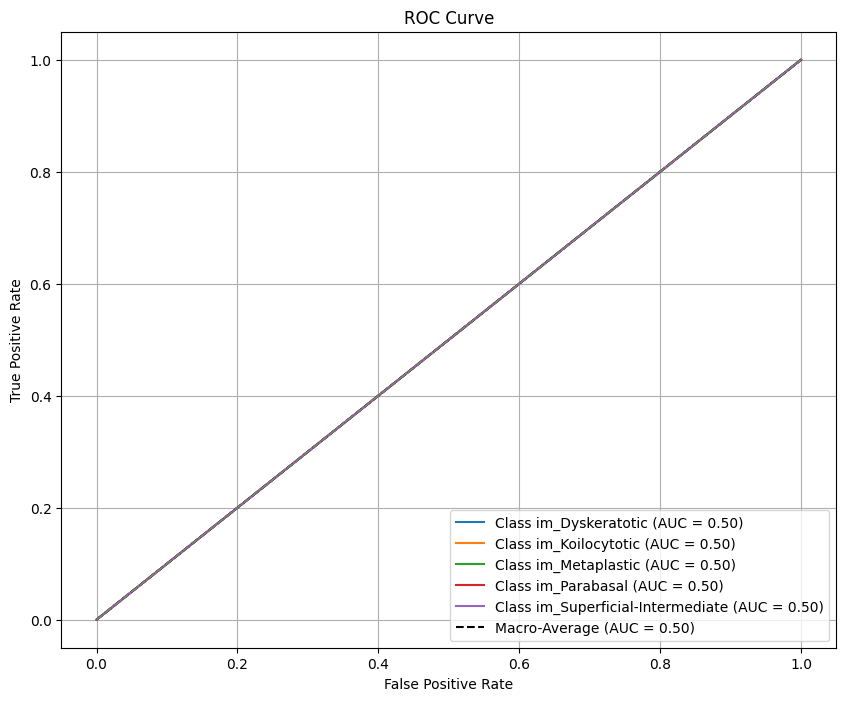

In [33]:
# Plot ROC Curve
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i, label in enumerate(test_generator.class_indices.keys()):
    plt.plot(fpr[i], tpr[i], label=f"Class {label} (AUC = {roc_auc[i]:.2f})")

fpr_micro, tpr_micro, _ = roc_curve(y_true_onehot.ravel(), y_pred_prob.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, linestyle='--', label=f'Macro-Average (AUC = {roc_auc_micro:.2f})', color='black')

plt.plot([0, 1], [0, 1], 'k--', color='gray')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [34]:
# Evaluation metrics
vgg_precision = report['weighted avg']['precision']
vgg_recall = report['weighted avg']['recall']
vgg_f1_score = report['weighted avg']['f1-score']

print("Precision: ", vgg_precision)
print("Recall: ", vgg_recall)
print("F1-Score: ", vgg_f1_score)

Precision:  0.04
Recall:  0.2
F1-Score:  0.06666666666666667


In [35]:
# Save the model
vgg_model.save('/kaggle/working/vgg_model.h5')
print("Model saved successfully!")

Model saved successfully!


In [36]:
# Inception
from tensorflow.keras.applications.inception_v3 import InceptionV3
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers[-20:]:
    layer.trainable = True

inc_model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(1024, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])

inc_model.compile(optimizers.Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [37]:
# Train the Model
inc_hist = inc_model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator,
    callbacks=[early_stopping]
)

Epoch 1/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 178s 885ms/step - accuracy: 0.5395 - loss: 20.4657 - val_accuracy: 0.7960 - val_loss: 15.2786
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 45s 377ms/step - accuracy: 0.8618 - loss: 13.8762 - val_accuracy: 0.8520 - val_loss: 10.8304
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 45s 376ms/step - accuracy: 0.8956 - loss: 9.8111 - val_accuracy: 0.8540 - val_loss: 7.7404
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 45s 376ms/step - accuracy: 0.8993 - loss: 7.0035 - val_accuracy: 0.9180 - val_loss: 5.4239
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 45s 375ms/step - accuracy: 0.9261 - loss: 4.9738 - val_accuracy: 0.9140 - val_loss: 3.9243
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 44s 375ms/step - accuracy: 0.9412 - loss: 3.5659 - val_accuracy: 0.9120 - val_loss: 2.9409
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 45s 376ms/step - accuracy: 0.9449 - loss: 2.5812 - val_accuracy: 0.9120 - val_loss: 2.1607
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 45s 378ms/step - accuracy: 0.9431 - lo

In [38]:
test_loss, test_acc = inc_model.evaluate(test_generator)
print("InceptionV3 Test Accuracy:", test_acc * 100, "%")

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.9343 - loss: 0.9541
InceptionV3 Test Accuracy: 93.59999895095825 %


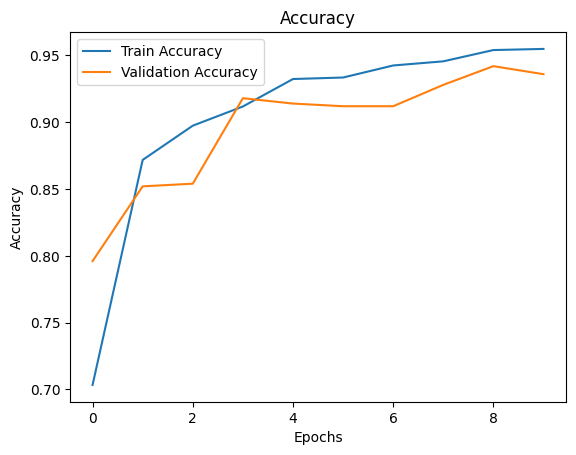

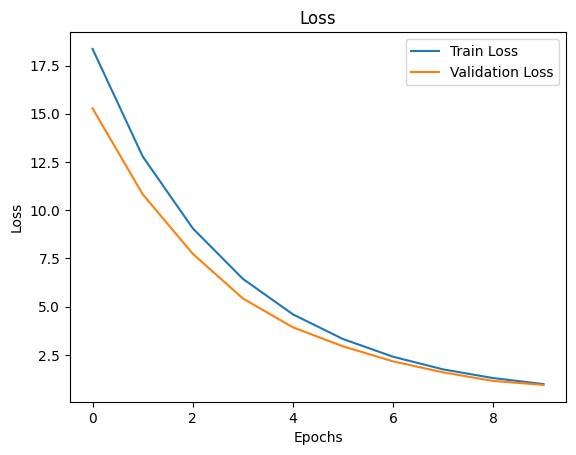

In [39]:
# Plot accuracy
plt.plot(inc_hist.history['accuracy'], label='Train Accuracy')
plt.plot(inc_hist.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(inc_hist.history['loss'], label='Train Loss')
plt.plot(inc_hist.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 346ms/step


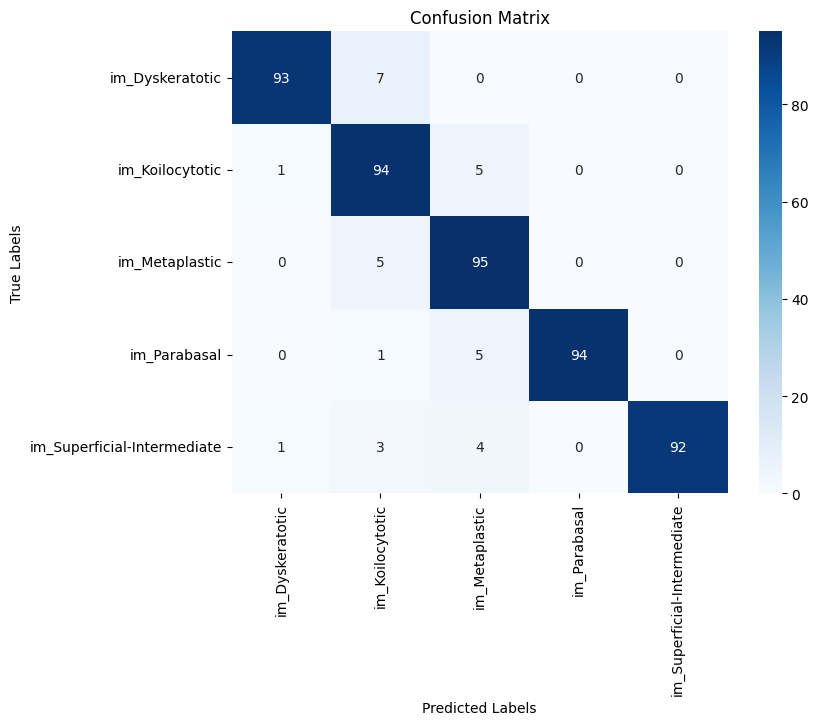

In [40]:
# Confusion matrix
y_pred_prob = inc_model.predict(test_generator)
y_true = test_generator.classes
y_pred = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [41]:
# Classification report
report = classification_report(y_true, y_pred, output_dict=True)
print("Classification Report:")
print(report)

Classification Report:
{'0': {'precision': 0.9789473684210527, 'recall': 0.93, 'f1-score': 0.9538461538461539, 'support': 100}, '1': {'precision': 0.8545454545454545, 'recall': 0.94, 'f1-score': 0.8952380952380952, 'support': 100}, '2': {'precision': 0.8715596330275229, 'recall': 0.95, 'f1-score': 0.9090909090909091, 'support': 100}, '3': {'precision': 1.0, 'recall': 0.94, 'f1-score': 0.9690721649484536, 'support': 100}, '4': {'precision': 1.0, 'recall': 0.92, 'f1-score': 0.9583333333333334, 'support': 100}, 'accuracy': 0.936, 'macro avg': {'precision': 0.9410104911988061, 'recall': 0.9360000000000002, 'f1-score': 0.9371161312913892, 'support': 500}, 'weighted avg': {'precision': 0.941010491198806, 'recall': 0.936, 'f1-score': 0.9371161312913892, 'support': 500}}


In [42]:
# Plot ROC Curve
n_classes = len(test_generator.class_indices)
y_true_onehot = label_binarize(y_true, classes=list(range(n_classes)))

# ROC-AUC score
inc_roc_auc = roc_auc_score(y_true_onehot, y_pred_prob, average='macro', multi_class='ovr')
print("Macro-Averaged ROC-AUC FOR InceptionV3: {:.4f}".format(inc_roc_auc))

Macro-Averaged ROC-AUC FOR InceptionV3: 0.9952


/tmp/ipykernel_23/2191934111.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', color='gray')


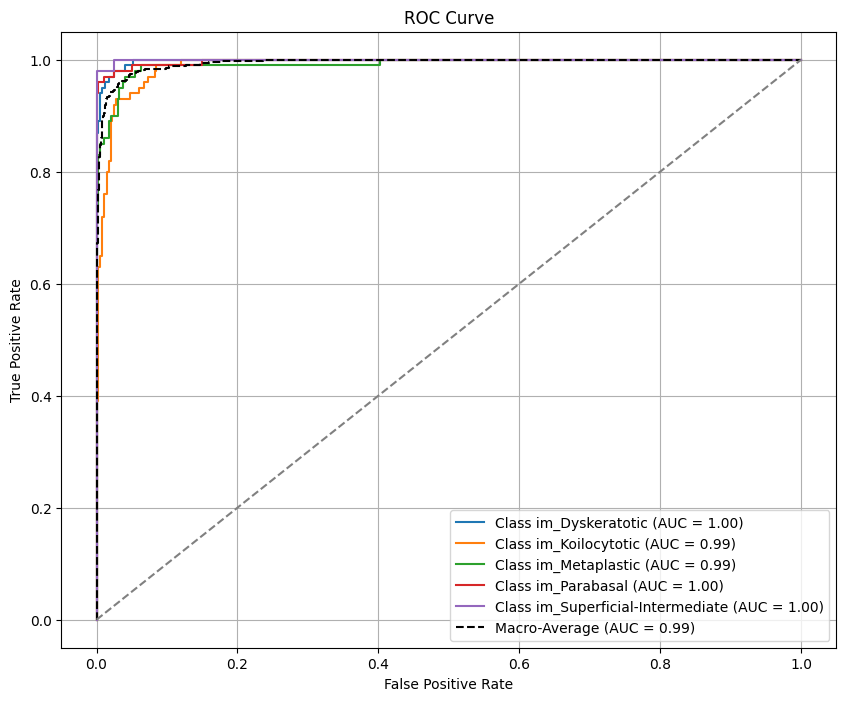

In [43]:
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i, label in enumerate(test_generator.class_indices.keys()):
    plt.plot(fpr[i], tpr[i], label=f"Class {label} (AUC = {roc_auc[i]:.2f})")

fpr_micro, tpr_micro, _ = roc_curve(y_true_onehot.ravel(), y_pred_prob.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, linestyle='--', label=f'Macro-Average (AUC = {roc_auc_micro:.2f})', color='black')

plt.plot([0, 1], [0, 1], 'k--', color='gray')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [44]:
# Evaluation metrics
inc_precision = report['weighted avg']['precision']
inc_recall = report['weighted avg']['recall']
inc_f1_score = report['weighted avg']['f1-score']

print("Precision: ", inc_precision)
print("Recall: ", inc_recall)
print("F1-Score: ", inc_f1_score)

Precision:  0.941010491198806
Recall:  0.936
F1-Score:  0.9371161312913892


In [45]:
# Save the model
inc_model.save('/kaggle/working/inc_model.h5')
print("Model saved successfully!")

Model saved successfully!


In [46]:
# EfficientNet B0 version
from tensorflow.keras.applications import EfficientNetB0
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers[-20:]:
    layer.trainable = True

eff_b0_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(1024, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])

eff_b0_model.compile(optimizers.Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [47]:
# Train the Model
eff_b0_hist = eff_b0_model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator,
    callbacks=[early_stopping]
)

Epoch 1/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 183s 906ms/step - accuracy: 0.5733 - loss: 11.9095 - val_accuracy: 0.2000 - val_loss: 10.6082
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 42s 358ms/step - accuracy: 0.8696 - loss: 8.7715 - val_accuracy: 0.0840 - val_loss: 8.4238
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 42s 353ms/step - accuracy: 0.9123 - loss: 6.5994 - val_accuracy: 0.2100 - val_loss: 7.2520
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 42s 354ms/step - accuracy: 0.9307 - loss: 4.8986 - val_accuracy: 0.2400 - val_loss: 5.6469
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 42s 355ms/step - accuracy: 0.9288 - loss: 3.6506 - val_accuracy: 0.3860 - val_loss: 4.2269
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 42s 355ms/step - accuracy: 0.9405 - loss: 2.6798 - val_accuracy: 0.5280 - val_loss: 3.2906
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 42s 356ms/step - accuracy: 0.9520 - loss: 1.9708 - val_accuracy: 0.7840 - val_loss: 2.0732
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 42s 355ms/step - accuracy: 0.9467 - loss

In [48]:
test_loss, test_acc = eff_b0_model.evaluate(test_generator)
print("EfficientNet B0 version Test Accuracy:", test_acc * 100, "%")

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9394 - loss: 0.7426
EfficientNet B0 version Test Accuracy: 92.00000166893005 %


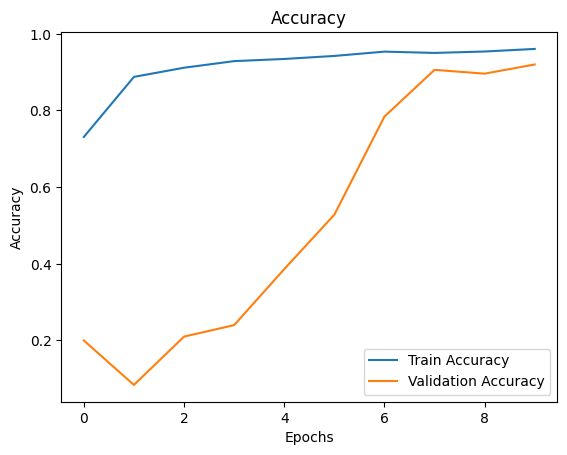

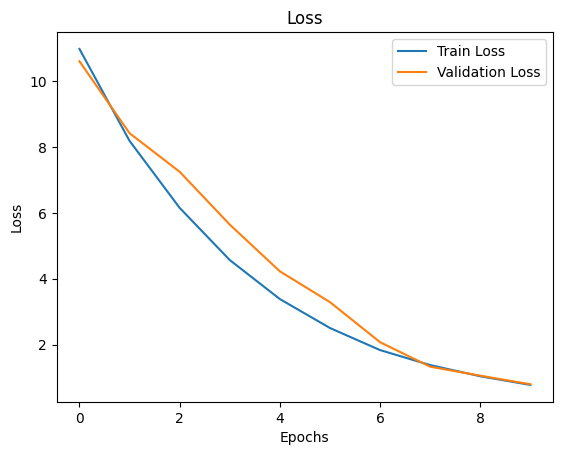

In [49]:
# Plot accuracy
plt.plot(eff_b0_hist.history['accuracy'], label='Train Accuracy')
plt.plot(eff_b0_hist.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(eff_b0_hist.history['loss'], label='Train Loss')
plt.plot(eff_b0_hist.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 321ms/step


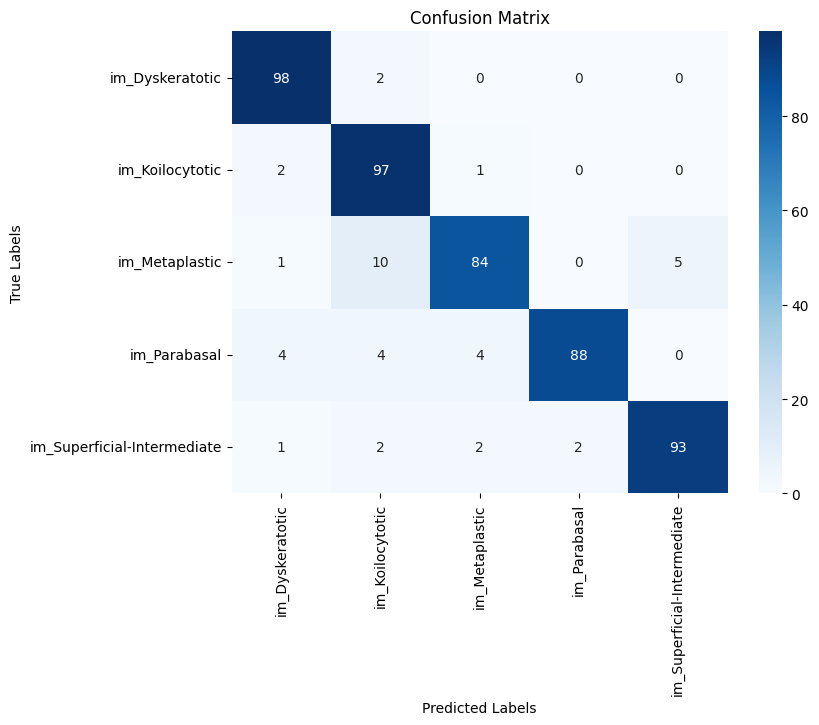

In [50]:
# Confusion matrix
y_pred_prob = eff_b0_model.predict(test_generator)
y_true = test_generator.classes
y_pred = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [51]:
# Classification report
report = classification_report(y_true, y_pred, output_dict=True)
print("Classification Report:")
print(report)

Classification Report:
{'0': {'precision': 0.9245283018867925, 'recall': 0.98, 'f1-score': 0.9514563106796116, 'support': 100}, '1': {'precision': 0.8434782608695652, 'recall': 0.97, 'f1-score': 0.9023255813953489, 'support': 100}, '2': {'precision': 0.9230769230769231, 'recall': 0.84, 'f1-score': 0.8795811518324608, 'support': 100}, '3': {'precision': 0.9777777777777777, 'recall': 0.88, 'f1-score': 0.9263157894736842, 'support': 100}, '4': {'precision': 0.9489795918367347, 'recall': 0.93, 'f1-score': 0.9393939393939393, 'support': 100}, 'accuracy': 0.92, 'macro avg': {'precision': 0.9235681710895587, 'recall': 0.9199999999999999, 'f1-score': 0.919814554555009, 'support': 500}, 'weighted avg': {'precision': 0.9235681710895588, 'recall': 0.92, 'f1-score': 0.919814554555009, 'support': 500}}


In [52]:
n_classes = len(test_generator.class_indices)
y_true_onehot = label_binarize(y_true, classes=list(range(n_classes)))

# ROC-AUC score
eff_b0_roc_auc = roc_auc_score(y_true_onehot, y_pred_prob, average='macro', multi_class='ovr')
print("Macro-Averaged ROC-AUC for EfficientNet version B0: {:.4f}".format(eff_b0_roc_auc))

Macro-Averaged ROC-AUC for EfficientNet version B0: 0.9949


/tmp/ipykernel_23/976383133.py:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', color='gray')


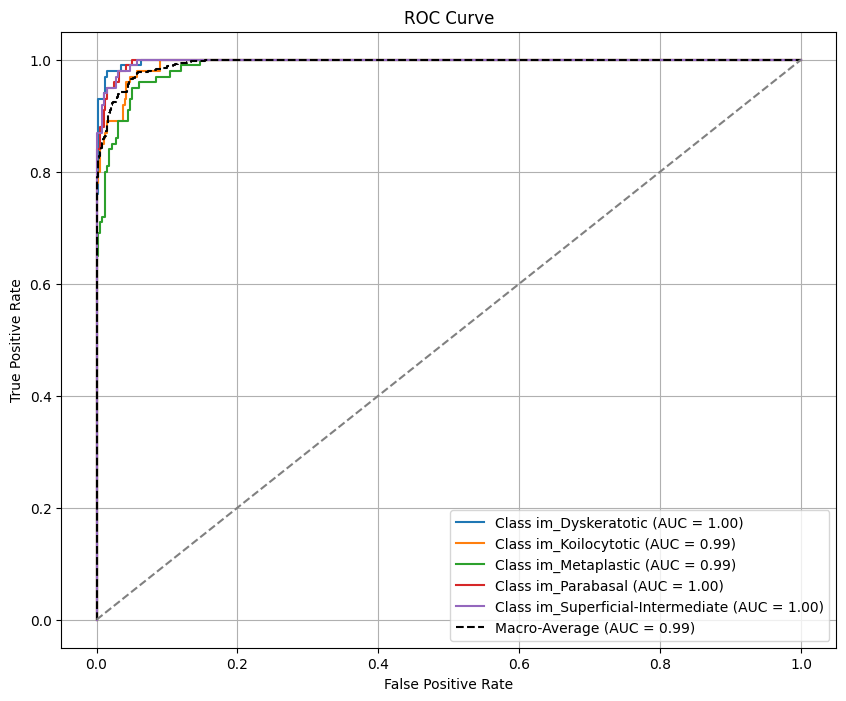

In [53]:
# Plot ROC Curve
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i, label in enumerate(test_generator.class_indices.keys()):
    plt.plot(fpr[i], tpr[i], label=f"Class {label} (AUC = {roc_auc[i]:.2f})")

fpr_micro, tpr_micro, _ = roc_curve(y_true_onehot.ravel(), y_pred_prob.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, linestyle='--', label=f'Macro-Average (AUC = {roc_auc_micro:.2f})', color='black')

plt.plot([0, 1], [0, 1], 'k--', color='gray')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [54]:
# Evaluation metrics
eff_b0_precision = report['weighted avg']['precision']
eff_b0_recall = report['weighted avg']['recall']
eff_b0_f1_score = report['weighted avg']['f1-score']

print("Precision: ", eff_b0_precision)
print("Recall: ", eff_b0_recall)
print("F1-Score: ", eff_b0_f1_score)

Precision:  0.9235681710895588
Recall:  0.92
F1-Score:  0.919814554555009


In [55]:
# Save the model
eff_b0_model.save('/kaggle/working/eff_b0_model.h5')
print("Model saved successfully!")

Model saved successfully!


In [56]:
# EfficientNet B7 version
from tensorflow.keras.applications import EfficientNetB7
base_model = EfficientNetB7(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers[-20:]:
    layer.trainable = True

eff_b7_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(1024, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])

eff_b7_model.compile(optimizers.Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

258076736/258076736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [57]:
# Train the Model
eff_b7_hist = eff_b7_model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator,
    callbacks=[early_stopping]
)

Epoch 1/10


I0000 00:00:1733769194.574767     133 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_10', 36 bytes spill stores, 36 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_11', 36 bytes spill stores, 36 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_12', 24 bytes spill stores, 24 bytes spill loads



111/111 ━━━━━━━━━━━━━━━━━━━━ 797s 4s/step - accuracy: 0.5880 - loss: 14.7194 - val_accuracy: 0.1340 - val_loss: 12.3939
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.9070 - loss: 10.0179 - val_accuracy: 0.1880 - val_loss: 9.3127
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.9334 - loss: 6.7498 - val_accuracy: 0.1960 - val_loss: 7.5034
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.9442 - loss: 4.4547 - val_accuracy: 0.2780 - val_loss: 4.9744
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.9607 - loss: 2.8767 - val_accuracy: 0.5400 - val_loss: 3.1964
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.9552 - loss: 1.8898 - val_accuracy: 0.7760 - val_loss: 1.9096
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.9674 - loss: 1.2018 - val_accuracy: 0.8760 - val_loss: 1.1269
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.9733 - loss: 0.7745 - val_accuracy: 0.

In [58]:
test_loss, test_acc = eff_b7_model.evaluate(test_generator)
print("EfficientNet B7 version Test Accuracy:", test_acc * 100, "%")

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 261ms/step - accuracy: 0.9435 - loss: 0.3930
EfficientNet B7 version Test Accuracy: 93.59999895095825 %


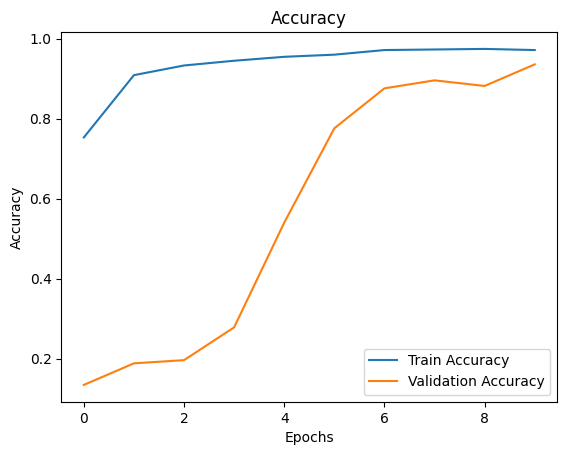

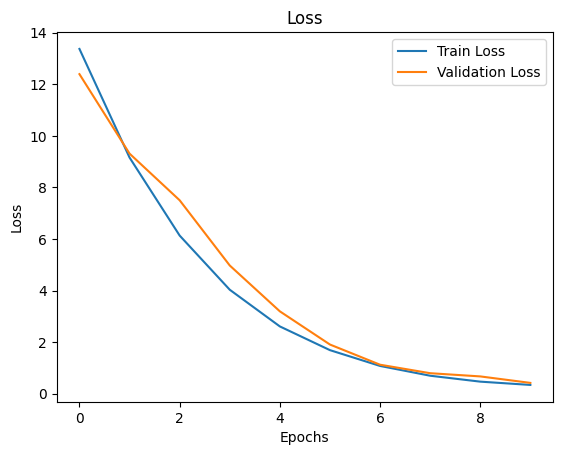

In [59]:
# Plot accuracy
plt.plot(eff_b7_hist.history['accuracy'], label='Train Accuracy')
plt.plot(eff_b7_hist.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(eff_b7_hist.history['loss'], label='Train Loss')
plt.plot(eff_b7_hist.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step 


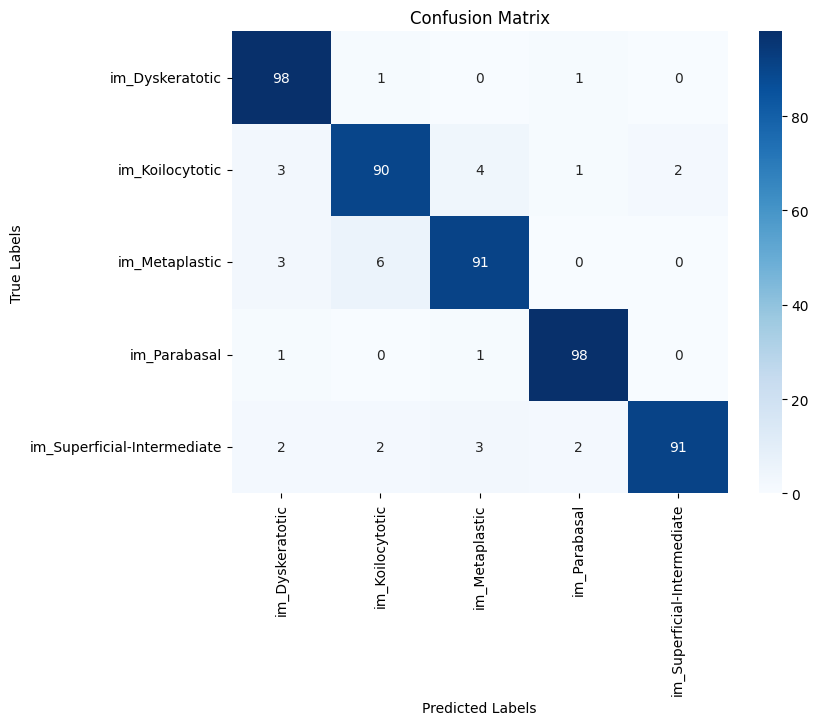

In [60]:
# Confusion matrix
y_pred_prob = eff_b7_model.predict(test_generator)
y_true = test_generator.classes
y_pred = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [61]:
# Classification report
report = classification_report(y_true, y_pred, output_dict=True)
print("Classification Report:")
print(report)

Classification Report:
{'0': {'precision': 0.9158878504672897, 'recall': 0.98, 'f1-score': 0.9468599033816426, 'support': 100}, '1': {'precision': 0.9090909090909091, 'recall': 0.9, 'f1-score': 0.9045226130653266, 'support': 100}, '2': {'precision': 0.9191919191919192, 'recall': 0.91, 'f1-score': 0.9145728643216081, 'support': 100}, '3': {'precision': 0.9607843137254902, 'recall': 0.98, 'f1-score': 0.9702970297029702, 'support': 100}, '4': {'precision': 0.978494623655914, 'recall': 0.91, 'f1-score': 0.9430051813471503, 'support': 100}, 'accuracy': 0.936, 'macro avg': {'precision': 0.9366899232263044, 'recall': 0.9359999999999999, 'f1-score': 0.9358515183637396, 'support': 500}, 'weighted avg': {'precision': 0.9366899232263045, 'recall': 0.936, 'f1-score': 0.9358515183637396, 'support': 500}}


In [62]:
n_classes = len(test_generator.class_indices)
y_true_onehot = label_binarize(y_true, classes=list(range(n_classes)))

# ROC-AUC score
eff_b7_roc_auc = roc_auc_score(y_true_onehot, y_pred_prob, average='macro', multi_class='ovr')
print("Macro-Averaged ROC-AUC for EfficientNet version B7: {:.4f}".format(eff_b7_roc_auc))

Macro-Averaged ROC-AUC for EfficientNet version B7: 0.9939


/tmp/ipykernel_23/976383133.py:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', color='gray')


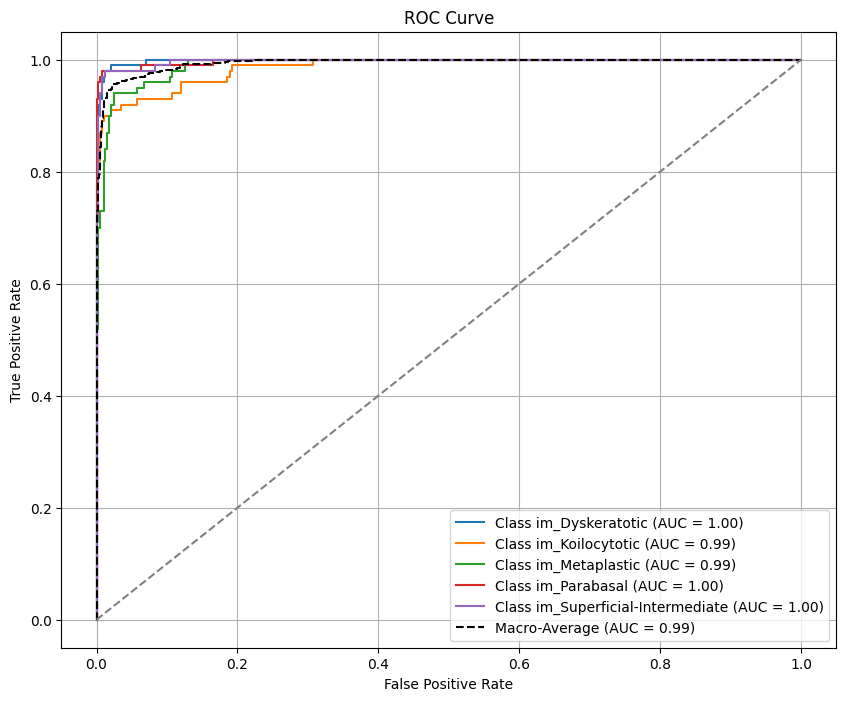

In [63]:
# Plot ROC Curve
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i, label in enumerate(test_generator.class_indices.keys()):
    plt.plot(fpr[i], tpr[i], label=f"Class {label} (AUC = {roc_auc[i]:.2f})")

fpr_micro, tpr_micro, _ = roc_curve(y_true_onehot.ravel(), y_pred_prob.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, linestyle='--', label=f'Macro-Average (AUC = {roc_auc_micro:.2f})', color='black')

plt.plot([0, 1], [0, 1], 'k--', color='gray')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [64]:
# Evaluation metrics
eff_b7_precision = report['weighted avg']['precision']
eff_b7_recall = report['weighted avg']['recall']
eff_b7_f1_score = report['weighted avg']['f1-score']

print("Precision: ", eff_b7_precision)
print("Recall: ", eff_b7_recall)
print("F1-Score: ", eff_b7_f1_score)

Precision:  0.9366899232263045
Recall:  0.936
F1-Score:  0.9358515183637396


In [65]:
# Save the model
eff_b7_model.save('/kaggle/working/eff_b7_model.h5')
print("Model saved successfully!")

Model saved successfully!


In [66]:
# MobileNetV2
from tensorflow.keras.applications import MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers[-20:]:
    layer.trainable = True

mob_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(1024, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')  
])

mob_model.compile(optimizers.Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [67]:
mob_hist = mob_model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator,
    callbacks=[early_stopping]
)

Epoch 1/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 105s 563ms/step - accuracy: 0.5527 - loss: 12.2071 - val_accuracy: 0.3700 - val_loss: 12.0575
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 41s 348ms/step - accuracy: 0.8633 - loss: 9.9922 - val_accuracy: 0.3440 - val_loss: 11.4977
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 41s 347ms/step - accuracy: 0.8969 - loss: 8.4371 - val_accuracy: 0.2380 - val_loss: 11.4655
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 42s 351ms/step - accuracy: 0.9238 - loss: 6.9892 - val_accuracy: 0.2540 - val_loss: 9.7595
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 41s 349ms/step - accuracy: 0.9190 - loss: 5.7887 - val_accuracy: 0.3940 - val_loss: 7.2290
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 41s 348ms/step - accuracy: 0.9364 - loss: 4.7522 - val_accuracy: 0.2980 - val_loss: 6.9385
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 41s 349ms/step - accuracy: 0.9288 - loss: 3.8996 - val_accuracy: 0.5880 - val_loss: 4.3112
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 42s 352ms/step - accuracy: 0.9386 - lo

In [68]:
test_loss, test_acc = mob_model.evaluate(test_generator)
print("MobileNetV2 Test Accuracy:", test_acc * 100, "%")

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6146 - loss: 3.3411
MobileNetV2 Test Accuracy: 46.39999866485596 %


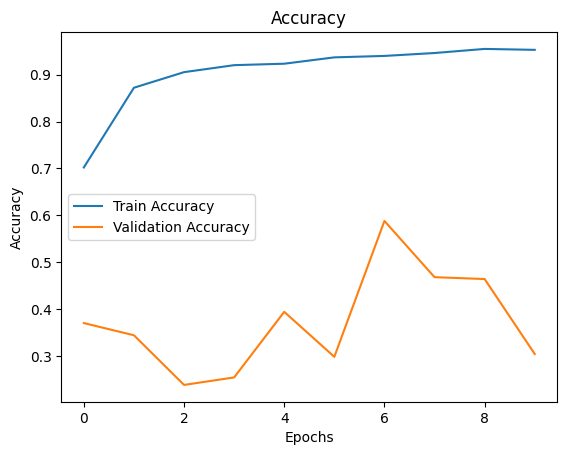

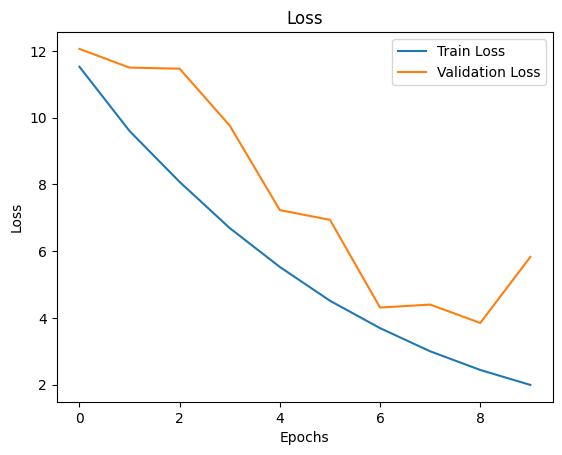

In [69]:
# Plot accuracy
plt.plot(mob_hist.history['accuracy'], label='Train Accuracy')
plt.plot(mob_hist.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(mob_hist.history['loss'], label='Train Loss')
plt.plot(mob_hist.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 181ms/step


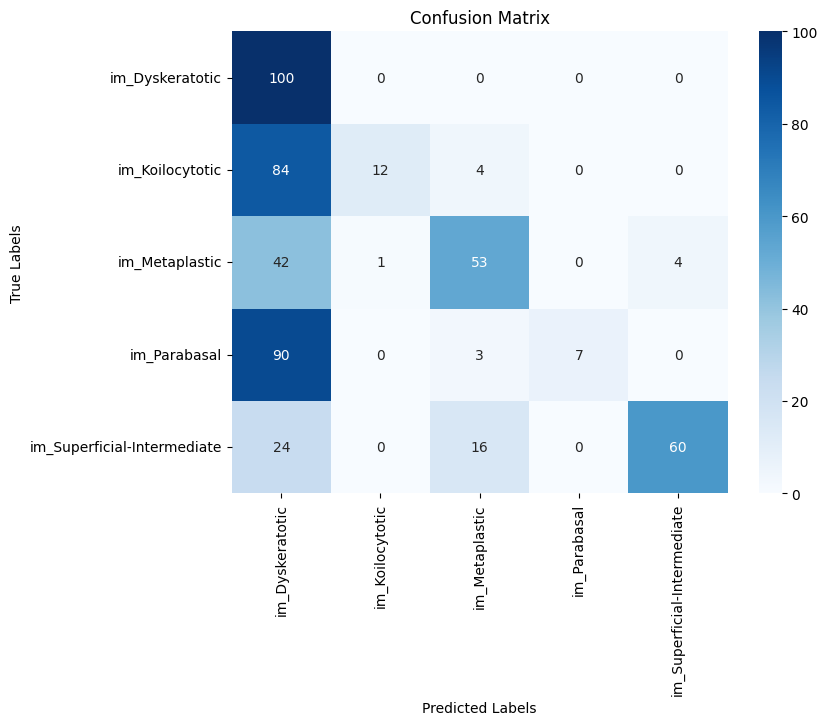

In [70]:
# Confusion matrix
y_pred_prob = mob_model.predict(test_generator)
y_true = test_generator.classes
y_pred = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [71]:
# Classification report
report = classification_report(y_true, y_pred, output_dict=True)
print("Classification Report:")
print(report)

Classification Report:
{'0': {'precision': 0.29411764705882354, 'recall': 1.0, 'f1-score': 0.45454545454545453, 'support': 100}, '1': {'precision': 0.9230769230769231, 'recall': 0.12, 'f1-score': 0.21238938053097348, 'support': 100}, '2': {'precision': 0.6973684210526315, 'recall': 0.53, 'f1-score': 0.6022727272727272, 'support': 100}, '3': {'precision': 1.0, 'recall': 0.07, 'f1-score': 0.13084112149532712, 'support': 100}, '4': {'precision': 0.9375, 'recall': 0.6, 'f1-score': 0.7317073170731707, 'support': 100}, 'accuracy': 0.464, 'macro avg': {'precision': 0.7704125982376756, 'recall': 0.4640000000000001, 'f1-score': 0.42635120018353057, 'support': 500}, 'weighted avg': {'precision': 0.7704125982376756, 'recall': 0.464, 'f1-score': 0.4263512001835306, 'support': 500}}


In [72]:
n_classes = len(test_generator.class_indices)
y_true_onehot = label_binarize(y_true, classes=list(range(n_classes)))

# ROC-AUC score
mob_roc_auc = roc_auc_score(y_true_onehot, y_pred_prob, average='macro', multi_class='ovr')
print("Macro-Averaged ROC-AUC for MobileNetV2: {:.4f}".format(mob_roc_auc))

Macro-Averaged ROC-AUC for MobileNetV2: 0.9340


/tmp/ipykernel_23/976383133.py:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', color='gray')


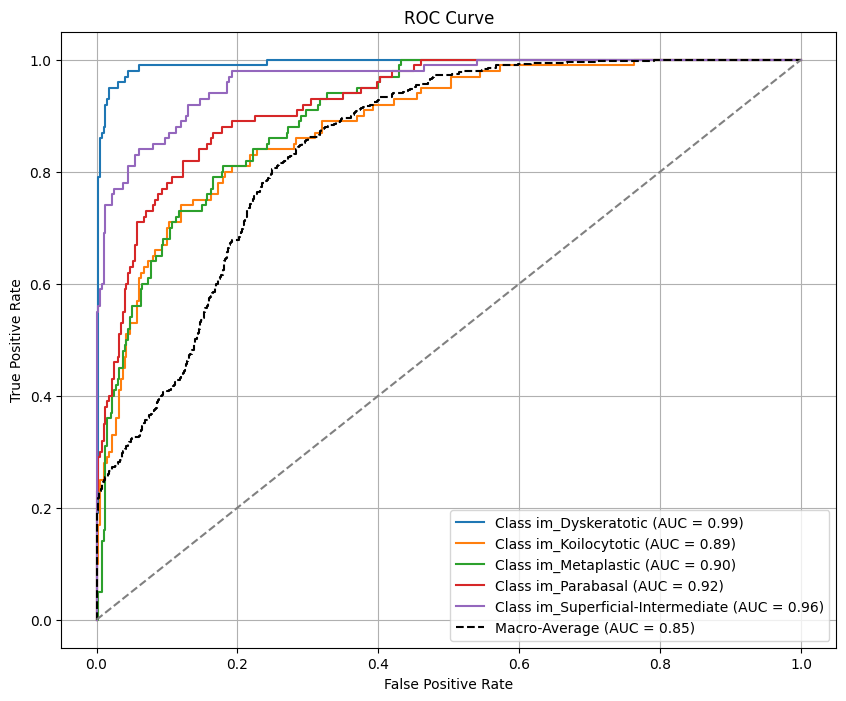

In [73]:
# Plot ROC Curve
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i, label in enumerate(test_generator.class_indices.keys()):
    plt.plot(fpr[i], tpr[i], label=f"Class {label} (AUC = {roc_auc[i]:.2f})")

fpr_micro, tpr_micro, _ = roc_curve(y_true_onehot.ravel(), y_pred_prob.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, linestyle='--', label=f'Macro-Average (AUC = {roc_auc_micro:.2f})', color='black')

plt.plot([0, 1], [0, 1], 'k--', color='gray')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [74]:
# Evaluation metrics
mob_precision = report['weighted avg']['precision']
mob_recall = report['weighted avg']['recall']
mob_f1_score = report['weighted avg']['f1-score']

print("Precision: ", mob_precision)
print("Recall: ", mob_recall)
print("F1-Score: ", mob_f1_score)

Precision:  0.7704125982376756
Recall:  0.464
F1-Score:  0.4263512001835306


In [75]:
# Save the model
mob_model.save('/kaggle/working/mob_model.h5')
print("Model saved successfully!")

Model saved successfully!


In [76]:
# MobileNetV3 Large
from tensorflow.keras.applications import MobileNetV3Large
base_model = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers[-20:]:
    layer.trainable = True

mob_v3_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(1024, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')  
])

mob_v3_model.compile(optimizers.Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [77]:
mob_v3_hist = mob_v3_model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator,
    callbacks=[early_stopping]
)

Epoch 1/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 123s 652ms/step - accuracy: 0.4855 - loss: 10.8933 - val_accuracy: 0.2000 - val_loss: 10.5684
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 41s 346ms/step - accuracy: 0.8264 - loss: 8.8859 - val_accuracy: 0.2000 - val_loss: 9.3693
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 41s 346ms/step - accuracy: 0.8798 - loss: 7.5386 - val_accuracy: 0.2000 - val_loss: 8.3619
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 41s 345ms/step - accuracy: 0.9087 - loss: 6.3666 - val_accuracy: 0.2000 - val_loss: 7.5916
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 40s 340ms/step - accuracy: 0.9222 - loss: 5.3723 - val_accuracy: 0.2000 - val_loss: 7.0330
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 41s 346ms/step - accuracy: 0.9292 - loss: 4.5100 - val_accuracy: 0.2000 - val_loss: 6.1151
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 41s 344ms/step - accuracy: 0.9369 - loss: 3.7660 - val_accuracy: 0.2000 - val_loss: 5.9560
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 41s 345ms/step - accuracy: 0.9465 - loss

In [78]:
test_loss, test_acc = mob_v3_model.evaluate(test_generator)
print("MobileNetV3 Test Accuracy:", test_acc * 100, "%")

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0883 - loss: 5.5345  
MobileNetV3 Test Accuracy: 20.000000298023224 %


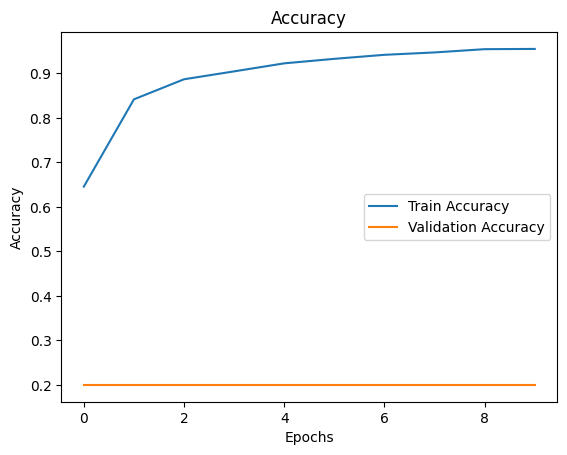

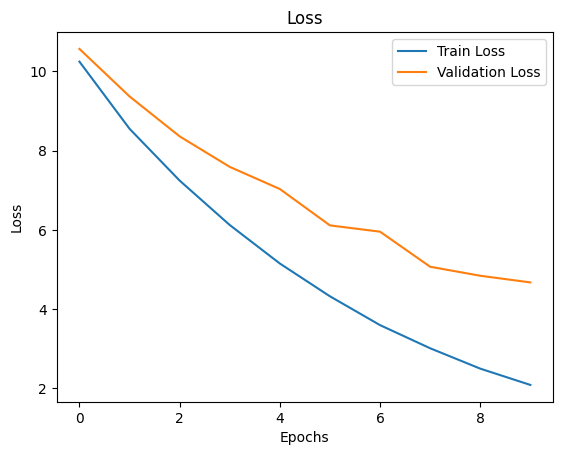

In [79]:
# Plot accuracy
plt.plot(mob_v3_hist.history['accuracy'], label='Train Accuracy')
plt.plot(mob_v3_hist.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(mob_v3_hist.history['loss'], label='Train Loss')
plt.plot(mob_v3_hist.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 235ms/step


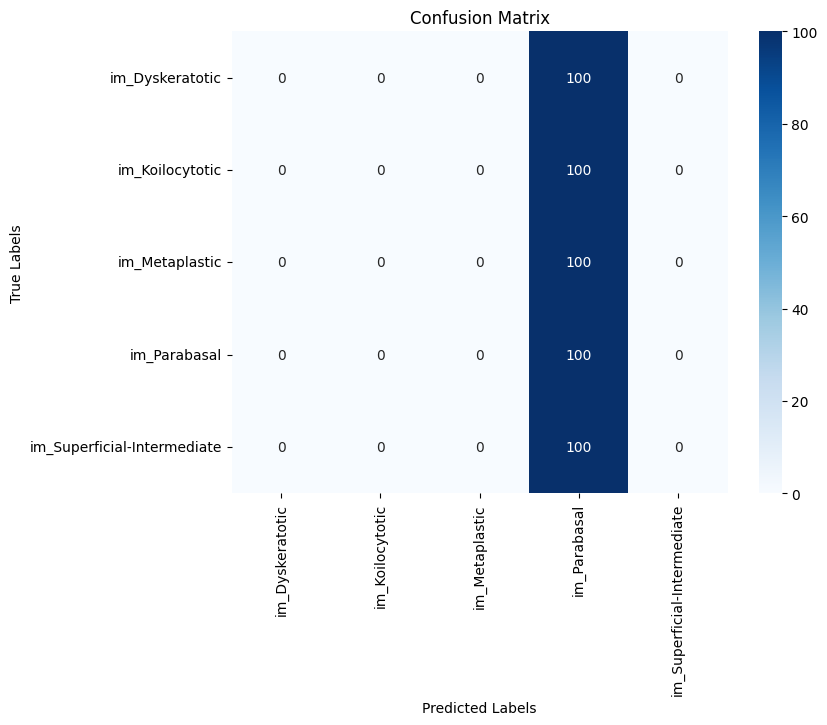

In [80]:
# Confusion matrix
y_pred_prob = mob_v3_model.predict(test_generator)
y_true = test_generator.classes
y_pred = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [81]:
# Classification report
report = classification_report(y_true, y_pred, output_dict=True)
print("Classification Report:")
print(report)

Classification Report:
{'0': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 100}, '1': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 100}, '2': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 100}, '3': {'precision': 0.2, 'recall': 1.0, 'f1-score': 0.33333333333333337, 'support': 100}, '4': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 100}, 'accuracy': 0.2, 'macro avg': {'precision': 0.04, 'recall': 0.2, 'f1-score': 0.06666666666666668, 'support': 500}, 'weighted avg': {'precision': 0.04, 'recall': 0.2, 'f1-score': 0.06666666666666667, 'support': 500}}


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [82]:
n_classes = len(test_generator.class_indices)
y_true_onehot = label_binarize(y_true, classes=list(range(n_classes)))

# ROC-AUC score
mob_v3_roc_auc = roc_auc_score(y_true_onehot, y_pred_prob, average='macro', multi_class='ovr')
print("Macro-Averaged ROC-AUC for MobileNetV3: {:.4f}".format(mob_v3_roc_auc))

Macro-Averaged ROC-AUC for MobileNetV3: 0.5840


/tmp/ipykernel_23/976383133.py:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', color='gray')


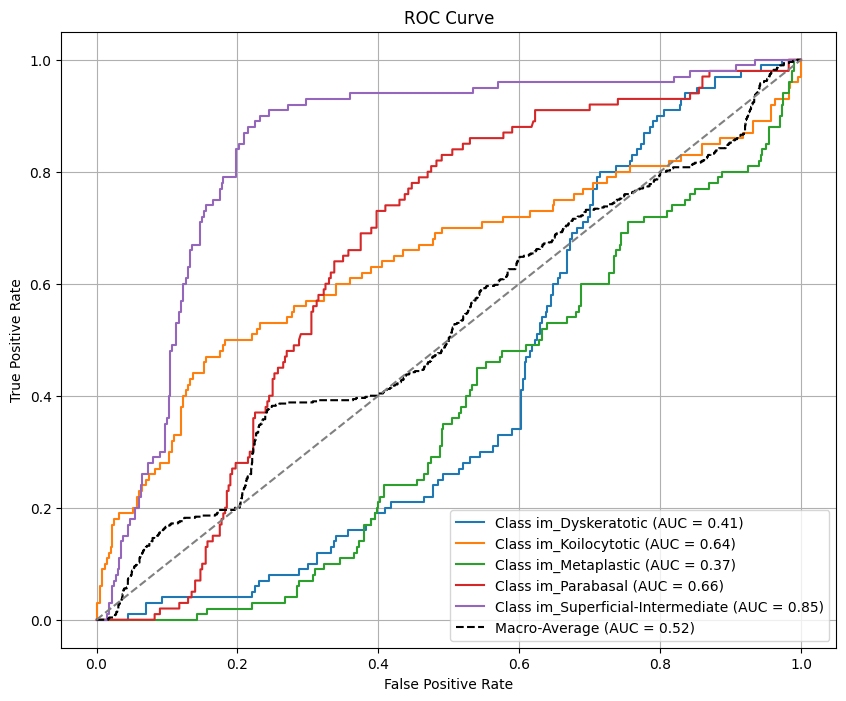

In [83]:
# Plot ROC Curve
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i, label in enumerate(test_generator.class_indices.keys()):
    plt.plot(fpr[i], tpr[i], label=f"Class {label} (AUC = {roc_auc[i]:.2f})")

fpr_micro, tpr_micro, _ = roc_curve(y_true_onehot.ravel(), y_pred_prob.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, linestyle='--', label=f'Macro-Average (AUC = {roc_auc_micro:.2f})', color='black')

plt.plot([0, 1], [0, 1], 'k--', color='gray')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [84]:
# Evaluation metrics
mob_v3_precision = report['weighted avg']['precision']
mob_v3_recall = report['weighted avg']['recall']
mob_v3_f1_score = report['weighted avg']['f1-score']

print("Precision: ", mob_v3_precision)
print("Recall: ", mob_v3_recall)
print("F1-Score: ", mob_v3_f1_score)

Precision:  0.04
Recall:  0.2
F1-Score:  0.06666666666666667


In [85]:
# Save the model
mob_v3_model.save('/kaggle/working/mob_v3_model.h5')
print("Model saved successfully!")

Model saved successfully!


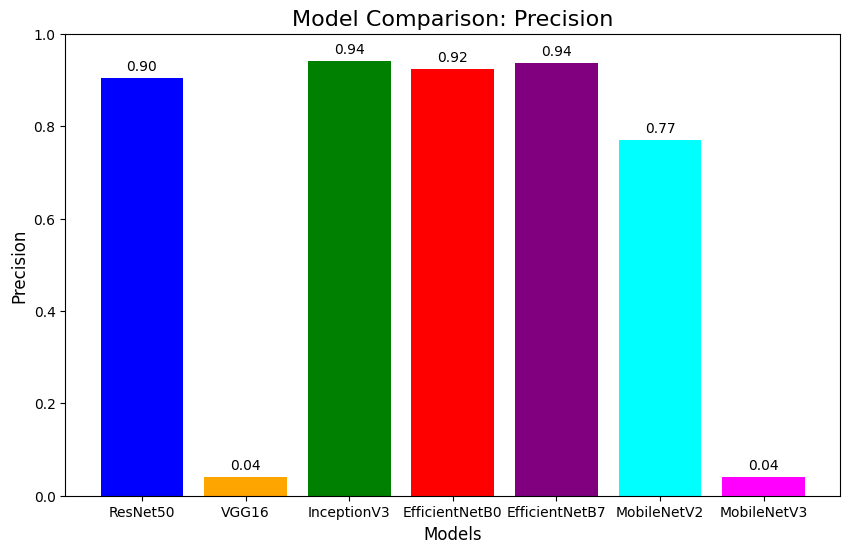

In [86]:
# Create the bar plot to compare precision
models = ['ResNet50', 'VGG16', 'InceptionV3', 'EfficientNetB0', 'EfficientNetB7', 'MobileNetV2', 'MobileNetV3']
precisions = [resnet_precision, vgg_precision, inc_precision, eff_b0_precision, eff_b7_precision, mob_precision, mob_v3_precision]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, precisions, color=['blue', 'orange', 'green', 'red', 'purple', 'cyan', 'magenta'])
plt.title('Model Comparison: Precision', fontsize=16)
plt.xlabel('Models', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.ylim(0, 1)  
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom', fontsize=10)
plt.show()

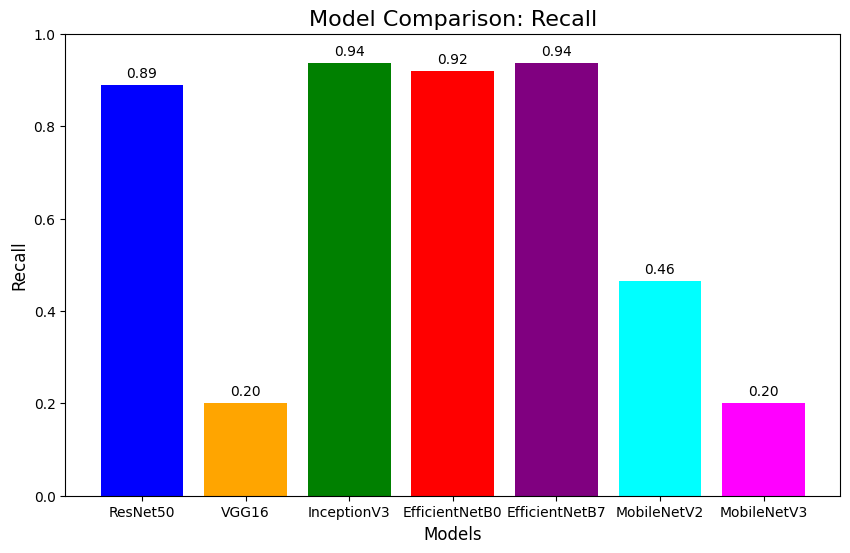

In [87]:
# Create the bar plot to compare recall
models = ['ResNet50', 'VGG16', 'InceptionV3', 'EfficientNetB0', 'EfficientNetB7', 'MobileNetV2', 'MobileNetV3']
recalls = [resnet_recall, vgg_recall, inc_recall, eff_b0_recall, eff_b7_recall, mob_recall, mob_v3_recall]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, recalls, color=['blue', 'orange', 'green', 'red', 'purple', 'cyan', 'magenta'])
plt.title('Model Comparison: Recall', fontsize=16)
plt.xlabel('Models', fontsize=12)
plt.ylabel('Recall', fontsize=12)
plt.ylim(0, 1)  
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom', fontsize=10)
plt.show()

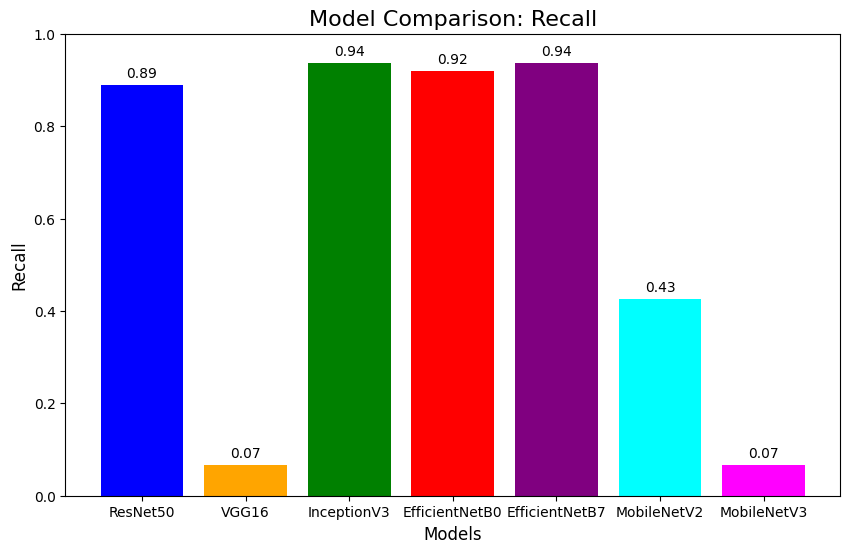

In [88]:
# Create the bar plot to compare f1-score
models = ['ResNet50', 'VGG16', 'InceptionV3', 'EfficientNetB0', 'EfficientNetB7', 'MobileNetV2', 'MobileNetV3']
recalls = [resnet_f1_score, vgg_f1_score, inc_f1_score, eff_b0_f1_score, eff_b7_f1_score, mob_f1_score, mob_v3_f1_score]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, recalls, color=['blue', 'orange', 'green', 'red', 'purple', 'cyan', 'magenta'])
plt.title('Model Comparison: Recall', fontsize=16)
plt.xlabel('Models', fontsize=12)
plt.ylabel('Recall', fontsize=12)
plt.ylim(0, 1)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom', fontsize=10)
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.8919 - loss: 2.1559
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 152ms/step - accuracy: 0.2462 - loss: 1.6472
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.9343 - loss: 0.9541
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9394 - loss: 0.7426
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 277ms/step - accuracy: 0.9435 - loss: 0.3930
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6146 - loss: 3.3411
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0883 - loss: 5.5345 


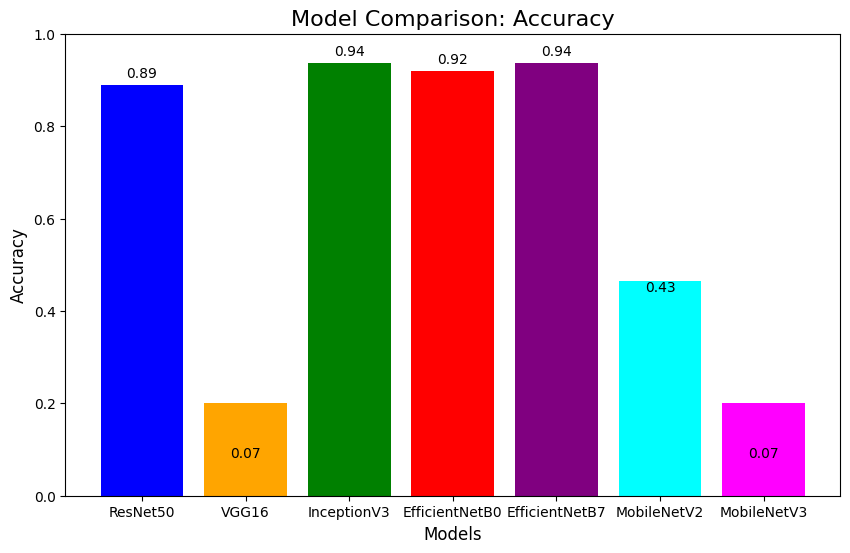

In [89]:
# Create the bar plot to compare accuracy
resnet_loss, resnet_accuracy = res_model.evaluate(test_generator)
vgg_loss, vgg_accuracy = vgg_model.evaluate(test_generator)
inc_loss, inc_accuracy = inc_model.evaluate(test_generator)
eff_b0_loss, eff_b0_accuracy = eff_b0_model.evaluate(test_generator)
eff_b7_loss, eff_b7_accuracy = eff_b7_model.evaluate(test_generator)
mob_loss, mob_accuracy = mob_model.evaluate(test_generator)
mob_v3_loss, mob_v3_accuracy = mob_v3_model.evaluate(test_generator)

models = ['ResNet50', 'VGG16', 'InceptionV3', 'EfficientNetB0', 'EfficientNetB7', 'MobileNetV2', 'MobileNetV3']
accuracies = [resnet_accuracy, vgg_accuracy, inc_accuracy, eff_b0_accuracy, eff_b7_accuracy, mob_accuracy, mob_v3_accuracy]

plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['blue', 'orange', 'green', 'red', 'purple', 'cyan', 'magenta'])
plt.title('Model Comparison: Accuracy', fontsize=16)
plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1)  
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom', fontsize=10)
plt.show()